# K-Means Clustering from Scratch (Pure Python + Pandas)
No numpy, no sklearn — random init, Euclidean distance, iterative centroid updates.
Model saved to `../Models/kmeans_scratch.json`.

## 1. Generate Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math, random, json, os
from sklearn.datasets import make_blobs

X_raw, y_true = make_blobs(
    n_samples=1500, centers=4, n_features=2,
    cluster_std=0.9, random_state=42
)

df = pd.DataFrame(X_raw, columns=['x1', 'x2'])
print(f"Dataset: {len(df):,} points  |  Features: 2  |  True clusters: 4")
df.head(3)

Dataset: 1,500 points  |  Features: 2  |  True clusters: 4


,x1,x2
0,-7.000505,-6.150382
1,-9.045688,6.491713
2,-8.388450,6.064147


## 2. Feature Standardisation (Pure Pandas)

In [2]:
col_means = df.mean()
col_stds  = df.std()

df_scaled = (df - col_means) / col_stds
print(f"After scaling — mean: {df_scaled.mean().round(6).tolist()}")
print(f"             — std : {df_scaled.std().round(4).tolist()}")

After scaling — mean: [-0.0, 0.0]
             — std : [1.0, 1.0]


## 3. K-Means Algorithm — Theory

K-Means partitions $n$ points into $k$ clusters by minimising the
**Within-Cluster Sum of Squares (WCSS / Inertia)**:

$$J = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

**Algorithm (Lloyd's):**
1. **Initialise** — pick $k$ random data points as starting centroids
2. **Assign** — label each point with the index of its nearest centroid
   $$c_i = \arg\min_j \|x_i - \mu_j\|^2$$
3. **Update** — move each centroid to the mean of its assigned points
   $$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$
4. **Repeat** steps 2–3 until centroids stop moving (convergence)

Guaranteed to converge but may reach a local minimum — run multiple
times with different initialisations and keep the best.

## 4. Distance & Assignment (Pure Python)

In [3]:
def euclidean(p1: list, p2: list) -> float:
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

def assign_clusters(data: pd.DataFrame, centroids: list) -> list:
    """Assign each row to the nearest centroid. Returns list of cluster indices."""
    labels = []
    for _, row in data.iterrows():
        point = row.tolist()
        dists = [euclidean(point, c) for c in centroids]
        labels.append(dists.index(min(dists)))
    return labels

def update_centroids(data: pd.DataFrame, labels: list, k: int) -> list:
    """Recompute each centroid as the mean of its assigned points."""
    centroids = []
    for j in range(k):
        cluster_pts = data[[labels[i] == j for i in range(len(labels))]]
        if len(cluster_pts) == 0:
            # Empty cluster: re-initialise to a random data point
            centroids.append(data.sample(1).iloc[0].tolist())
        else:
            centroids.append(cluster_pts.mean().tolist())
    return centroids

def inertia(data: pd.DataFrame, labels: list, centroids: list) -> float:
    total = 0.0
    for i, (_, row) in enumerate(data.iterrows()):
        total += euclidean(row.tolist(), centroids[labels[i]]) ** 2
    return total

## 5. K-Means Training Loop

In [4]:
def kmeans(data: pd.DataFrame, k: int, max_iter=300, tol=1e-4, random_state=42):
    """
    Lloyd's K-Means from scratch.
    Returns: labels (list), centroids (list of lists), n_iter (int), inertia_history (list)
    """
    random.seed(random_state)
    init_idx  = random.sample(range(len(data)), k)
    centroids = [data.iloc[i].tolist() for i in init_idx]

    inertia_history = []
    labels = [0] * len(data)

    for iteration in range(1, max_iter + 1):
        labels       = assign_clusters(data, centroids)
        new_centroids = update_centroids(data, labels, k)

        # Check convergence — max centroid shift
        max_shift = max(
            euclidean(old, new)
            for old, new in zip(centroids, new_centroids)
        )
        centroids = new_centroids
        current_inertia = inertia(data, labels, centroids)
        inertia_history.append(current_inertia)

        if iteration % 5 == 0 or iteration == 1:
            print(f"Iter {iteration:>3} | Inertia: {current_inertia:.4f} | Max shift: {max_shift:.6f}")

        if max_shift < tol:
            print(f"Converged at iteration {iteration}.")
            break

    return labels, centroids, iteration, inertia_history


K = 4
labels, centroids, n_iter, inertia_history = kmeans(df_scaled, k=K)

Iter   1 | Inertia: 1090.2551 | Max shift: 1.017936
Iter   5 | Inertia: 71.9676 | Max shift: 0.000000
Converged at iteration 5.


## 6. Inertia Curve

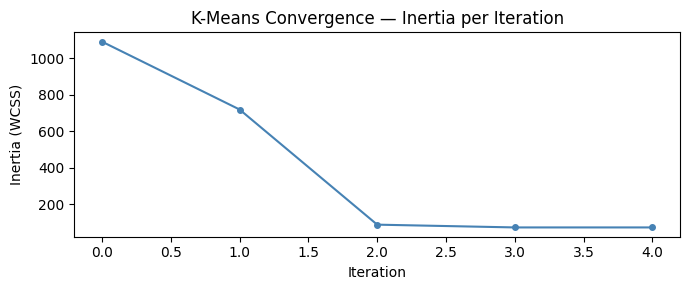

In [5]:
plt.figure(figsize=(7, 3))
plt.plot(inertia_history, marker='o', markersize=4, color='steelblue')
plt.xlabel('Iteration'); plt.ylabel('Inertia (WCSS)')
plt.title('K-Means Convergence — Inertia per Iteration')
plt.tight_layout(); plt.show()

## 7. Cluster Visualisation

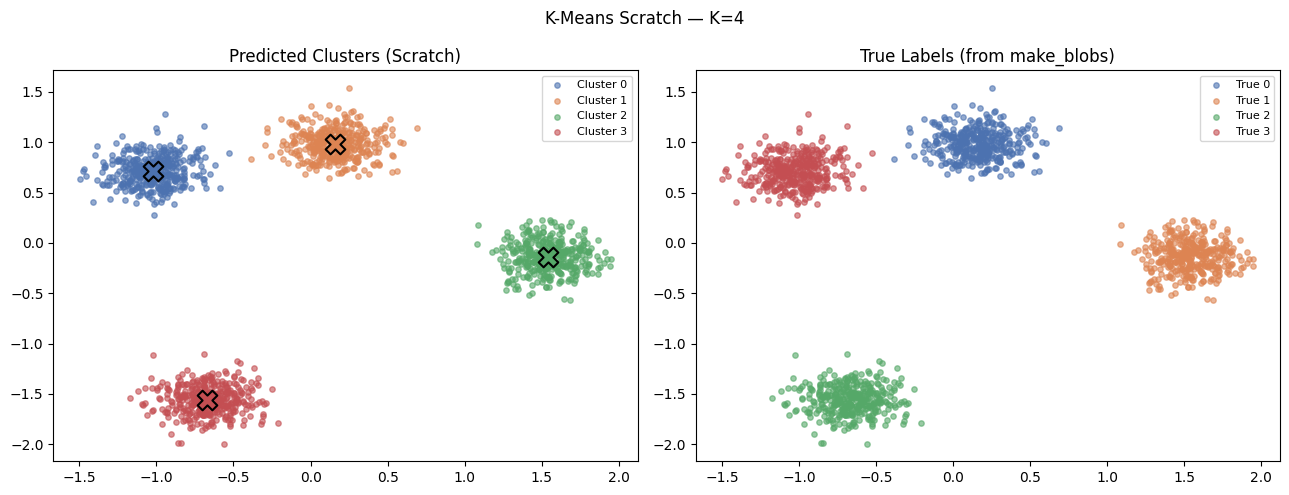

In [6]:
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Predicted clusters
for j in range(K):
    pts = df_scaled[[labels[i] == j for i in range(len(labels))]]
    ax1.scatter(pts['x1'], pts['x2'], s=15, alpha=0.6, color=colors[j], label=f'Cluster {j}')
    ax1.scatter(*centroids[j], s=200, marker='X', color=colors[j], edgecolors='black', linewidths=1.5)
ax1.set_title('Predicted Clusters (Scratch)')
ax1.legend(fontsize=8)

# Ground truth
for j in range(K):
    mask = [y_true[i] == j for i in range(len(y_true))]
    pts  = df_scaled[mask]
    ax2.scatter(pts['x1'], pts['x2'], s=15, alpha=0.6, color=colors[j], label=f'True {j}')
ax2.set_title('True Labels (from make_blobs)')
ax2.legend(fontsize=8)

plt.suptitle('K-Means Scratch — K=4', fontsize=12)
plt.tight_layout(); plt.show()

## 8. Elbow Method — Choosing K

Run K-Means for k = 1…10 and plot inertia. The 'elbow' — where the
rate of decrease sharply flattens — is a heuristic for the optimal k.

Running elbow method (this takes a minute with pure Python)...
Iter   1 | Inertia: 2998.0000 | Max shift: 0.923181
Converged at iteration 2.
  k=1 | Inertia: 2998.00
Iter   1 | Inertia: 1823.4198 | Max shift: 1.189249
Iter   5 | Inertia: 1652.5401 | Max shift: 0.001781
Converged at iteration 6.
  k=2 | Inertia: 1652.54
Iter   1 | Inertia: 1794.0725 | Max shift: 0.865877
Iter   5 | Inertia: 1364.7165 | Max shift: 0.000000
Converged at iteration 5.
  k=3 | Inertia: 1364.72
Iter   1 | Inertia: 1090.2551 | Max shift: 1.017936
Iter   5 | Inertia: 71.9676 | Max shift: 0.000000
Converged at iteration 5.
  k=4 | Inertia: 71.97
Iter   1 | Inertia: 1083.2411 | Max shift: 1.017936
Iter   5 | Inertia: 66.3464 | Max shift: 0.002584
Converged at iteration 6.
  k=5 | Inertia: 66.35
Iter   1 | Inertia: 1033.9425 | Max shift: 1.473946
Iter   5 | Inertia: 61.6368 | Max shift: 0.095454
Iter  10 | Inertia: 59.4771 | Max shift: 0.009442
Converged at iteration 13.
  k=6 | Inertia: 59.44
Iter   1 | Inertia: 

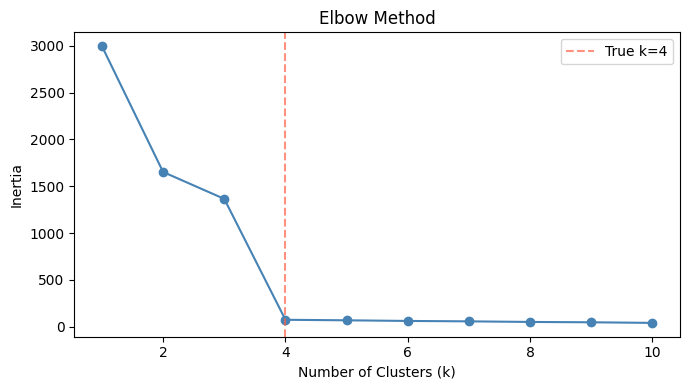

In [7]:
print("Running elbow method (this takes a minute with pure Python)...")
inertias = []
K_range  = range(1, 11)
for k in K_range:
    lbl, ctr, _, _ = kmeans(df_scaled, k=k, random_state=42)
    inertias.append(inertia(df_scaled, lbl, ctr))
    print(f"  k={k} | Inertia: {inertias[-1]:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue')
plt.axvline(4, linestyle='--', color='tomato', alpha=0.7, label='True k=4')
plt.xlabel('Number of Clusters (k)'); plt.ylabel('Inertia')
plt.title('Elbow Method'); plt.legend()
plt.tight_layout(); plt.show()

## 9. Evaluation Metrics

In [8]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

X_np = df_scaled.values
lbl_arr = np.array(labels)

sil = silhouette_score(X_np, lbl_arr)
dbs = davies_bouldin_score(X_np, lbl_arr)
chs = calinski_harabasz_score(X_np, lbl_arr)
inn = inertia_history[-1]

print(f"Inertia (WCSS)          : {inn:.4f}  (lower = tighter clusters)")
print(f"Silhouette Score        : {sil:.4f}  (higher = better, range -1..1)")
print(f"Davies-Bouldin Score    : {dbs:.4f}  (lower = better)")
print(f"Calinski-Harabasz Score : {chs:.4f}  (higher = better)")
print(f"Iterations to converge  : {n_iter}")

Inertia (WCSS)          : 71.9676  (lower = tighter clusters)
Silhouette Score        : 0.8170  (higher = better, range -1..1)
Davies-Bouldin Score    : 0.2571  (lower = better)
Calinski-Harabasz Score : 20274.6064  (higher = better)
Iterations to converge  : 5


## 10. Save Model to `../Models/`

In [9]:
os.makedirs('../Models', exist_ok=True)

model_data = {
    'k':           K,
    'centroids':   centroids,          # list of lists
    'n_iter':      n_iter,
    'inertia':     inertia_history[-1],
    'col_means':   col_means.to_dict(),
    'col_stds':    col_stds.to_dict()
}

save_path = '../Models/kmeans_scratch.json'
with open(save_path, 'w') as f:
    json.dump(model_data, f)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/kmeans_scratch.json  (0.4 KB)
